# 02. Preprocessing Pipeline

Notebook này giải thích rõ **pipeline tiền xử lý** và thêm các sơ đồ để bạn nhìn được dữ liệu thay đổi như thế nào qua từng bước.

In [9]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

DEFAULT_ROOT = Path(r"C:\vscode\hoctap\Customer-Churn-Analysis")

def find_project_root(start_path: Path) -> Path:
    candidates = [start_path, *start_path.parents, DEFAULT_ROOT]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'configs').exists():
            return candidate
    raise FileNotFoundError('Không tìm thấy thư mục project chứa src/ và configs/.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load_data import load_dataset
from src.data.preprocess import clean_dataframe, encode_dataframe, preprocess_pipeline
from src.utils.config import load_project_config

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)

config = load_project_config(PROJECT_ROOT / 'configs' / 'config.yaml')
df_raw = load_dataset(PROJECT_ROOT / config['paths']['raw_data'])
df_raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Kiểm tra vấn đề của `TotalCharges`

In [10]:
blank_mask = df_raw['TotalCharges'].astype(str).str.strip() == ''
blank_total_charges = blank_mask.sum()
print('Blank TotalCharges rows:', blank_total_charges)
df_raw.loc[blank_mask, ['tenure', 'MonthlyCharges', 'TotalCharges']].head(10)

Blank TotalCharges rows: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


In [11]:
raw_missing = df_raw.isna().sum().sort_values(ascending=False)
clean_df = clean_dataframe(df_raw)
clean_missing = clean_df.isna().sum().sort_values(ascending=False)

compare_missing = pd.DataFrame({
    'raw_missing': raw_missing,
    'after_clean_missing': clean_missing
}).fillna(0)
compare_missing.head(10)

,raw_missing,after_clean_missing
Churn,0,0.0
Contract,0,0.0
Dependents,0,0.0
DeviceProtection,0,0.0
InternetService,0,0.0
MonthlyCharges,0,0.0
MultipleLines,0,0.0
OnlineBackup,0,0.0
OnlineSecurity,0,0.0
PaperlessBilling,0,0.0


## 2. Làm sạch dữ liệu và so sánh trước/sau

In [12]:
df_clean = clean_dataframe(df_raw)
print('Raw shape:', df_raw.shape)
print('Clean shape:', df_clean.shape)
print('customerID in clean data:', 'customerID' in df_clean.columns)
df_clean.head()

Raw shape: (7043, 21)
Clean shape: (7043, 20)
customerID in clean data: False


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


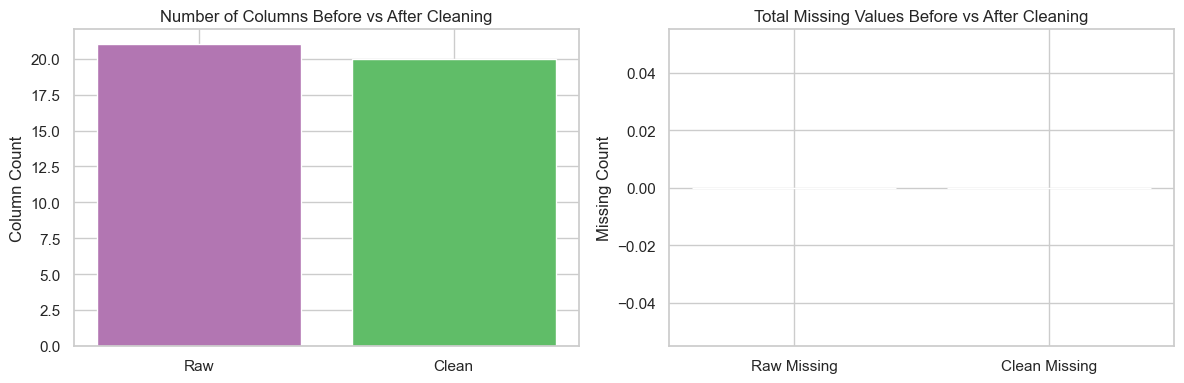

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Raw', 'Clean'], [df_raw.shape[1], df_clean.shape[1]], color=['#B276B2', '#60BD68'])
axes[0].set_title('Number of Columns Before vs After Cleaning')
axes[0].set_ylabel('Column Count')

axes[1].bar(['Raw Missing', 'Clean Missing'], [df_raw.isna().sum().sum(), df_clean.isna().sum().sum()], color=["#F573AD", '#5DA5DA'])
axes[1].set_title('Total Missing Values Before vs After Cleaning')
axes[1].set_ylabel('Missing Count')

plt.tight_layout()
plt.show()

## 3. Encode dữ liệu và xem loại feature

In [14]:
encoded_df, encoders, numeric_columns, categorical_columns = encode_dataframe(df_clean, target_column='Churn')
print('Numeric columns:', numeric_columns)
print('Categorical columns:', categorical_columns)
encoded_df.head()

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


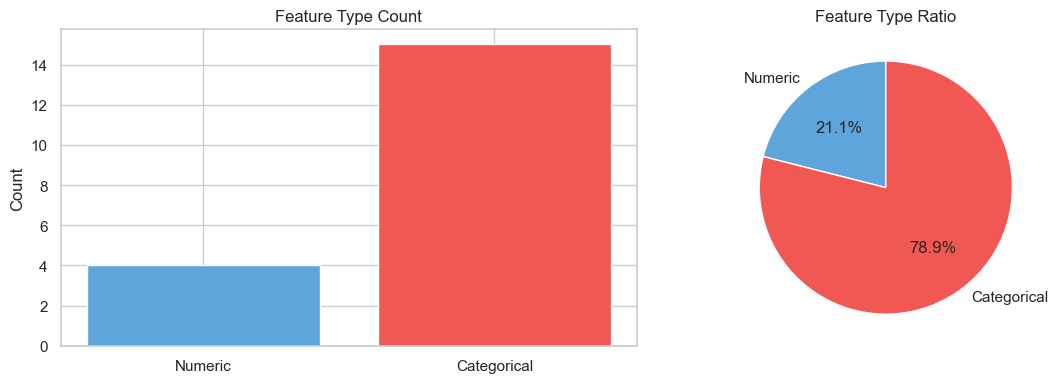

In [15]:
feature_type_counts = pd.Series({
    'Numeric': len(numeric_columns),
    'Categorical': len(categorical_columns)
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(feature_type_counts.index, feature_type_counts.values, color=['#5DA5DA', '#F15854'])
axes[0].set_title('Feature Type Count')
axes[0].set_ylabel('Count')

axes[1].pie(feature_type_counts.values, labels=feature_type_counts.index, autopct='%1.1f%%', startangle=90, colors=['#5DA5DA', '#F15854'], wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Feature Type Ratio')

plt.tight_layout()
plt.show()

## 4. Chạy toàn bộ pipeline preprocessing

In [16]:
bundle = preprocess_pipeline(df_raw, config)
print('X_train shape:', bundle.X_train.shape)
print('X_test shape:', bundle.X_test.shape)
print('y_train shape:', bundle.y_train.shape)
print('y_test shape:', bundle.y_test.shape)
bundle.X_train.head()

X_train shape: (8278, 19)
X_test shape: (1409, 19)
y_train shape: (8278,)
y_test shape: (1409,)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,1,-0.406521,0,0,0.291580,0,1,0,0,0,2,0,2,2,0,0,2,-0.662137,-0.175148
1,1,-0.406521,1,1,-0.541721,1,0,1,2,0,0,0,0,0,0,0,3,0.237689,-0.424966
2,1,-0.406521,1,1,-0.625051,0,1,0,2,2,0,2,0,0,2,0,3,-0.962659,-0.679825
3,0,-0.406521,1,0,-0.083406,1,0,0,0,2,2,0,2,2,2,1,1,0.182101,-0.082482
4,1,-0.406521,1,1,-1.125031,1,0,0,0,0,0,0,0,0,0,0,2,-0.823689,-0.927690


## 5. So sánh phân phối lớp trước và sau `SMOTENC`

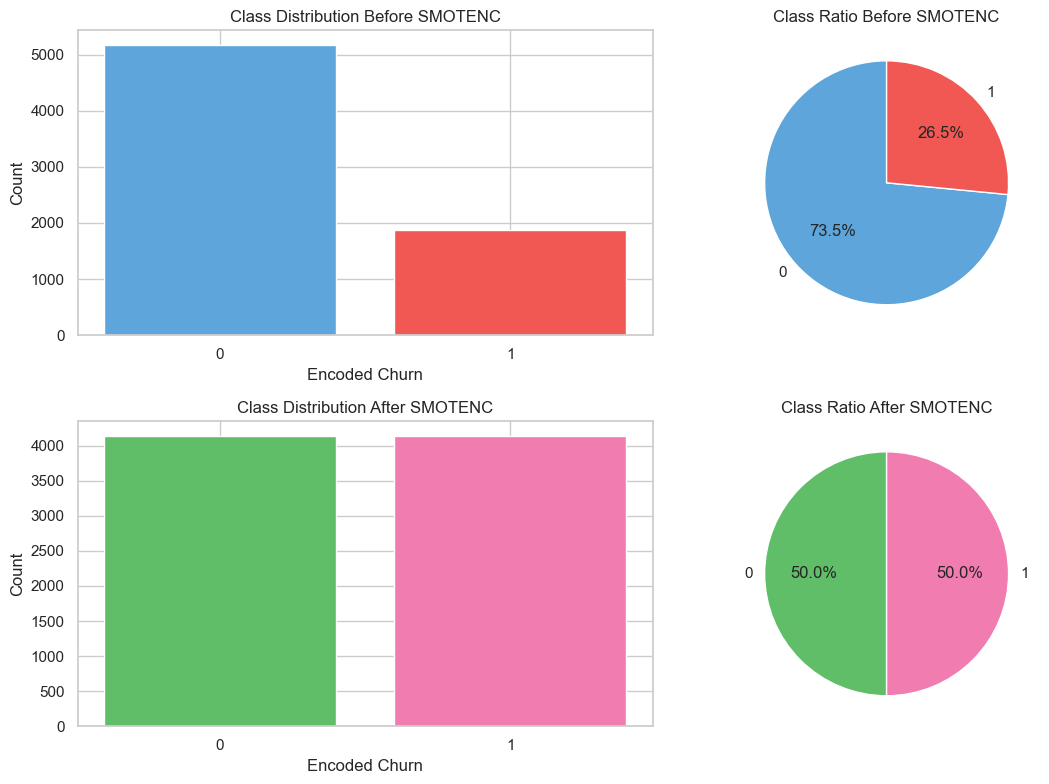

In [17]:
target_counts_before = encoded_df['Churn'].value_counts().sort_index()
target_counts_after = bundle.y_train.value_counts().sort_index()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].bar(target_counts_before.index.astype(str), target_counts_before.values, color=['#5DA5DA', '#F15854'])
axes[0, 0].set_title('Class Distribution Before SMOTENC')
axes[0, 0].set_xlabel('Encoded Churn')
axes[0, 0].set_ylabel('Count')

axes[0, 1].pie(target_counts_before.values, labels=target_counts_before.index.astype(str), autopct='%1.1f%%', startangle=90, colors=['#5DA5DA', '#F15854'], wedgeprops={'edgecolor': 'white'})
axes[0, 1].set_title('Class Ratio Before SMOTENC')

axes[1, 0].bar(target_counts_after.index.astype(str), target_counts_after.values, color=['#60BD68', '#F17CB0'])
axes[1, 0].set_title('Class Distribution After SMOTENC')
axes[1, 0].set_xlabel('Encoded Churn')
axes[1, 0].set_ylabel('Count')

axes[1, 1].pie(target_counts_after.values, labels=target_counts_after.index.astype(str), autopct='%1.1f%%', startangle=90, colors=['#60BD68', '#F17CB0'], wedgeprops={'edgecolor': 'white'})
axes[1, 1].set_title('Class Ratio After SMOTENC')

plt.tight_layout()
plt.show()

## 6. Tương quan giữa các biến sau encode

Thay vì heatmap toàn bộ rất rối, ta lấy các biến có tương quan mạnh nhất với `Churn`.

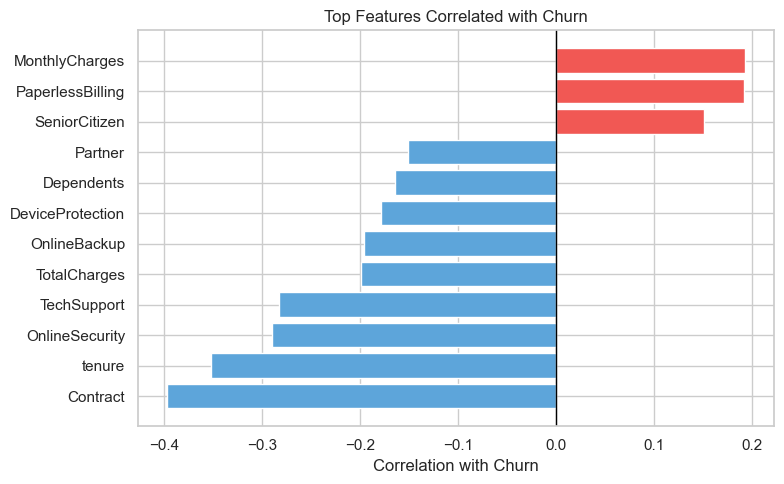

Contract           -0.396713
tenure             -0.352229
OnlineSecurity     -0.289309
TechSupport        -0.282492
TotalCharges       -0.199037
OnlineBackup       -0.195525
DeviceProtection   -0.178134
Dependents         -0.164221
Partner            -0.150448
SeniorCitizen       0.150889
PaperlessBilling    0.191825
MonthlyCharges      0.193356
Name: Churn, dtype: float64

In [18]:
corr_with_target = encoded_df.corr(numeric_only=True)['Churn'].drop('Churn').sort_values(key=np.abs, ascending=False)
top_corr = corr_with_target.head(12).sort_values()

plt.figure(figsize=(8, 5))
plt.barh(top_corr.index, top_corr.values, color=['#F15854' if x > 0 else '#5DA5DA' for x in top_corr.values])
plt.title('Top Features Correlated with Churn')
plt.xlabel('Correlation with Churn')
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

top_corr

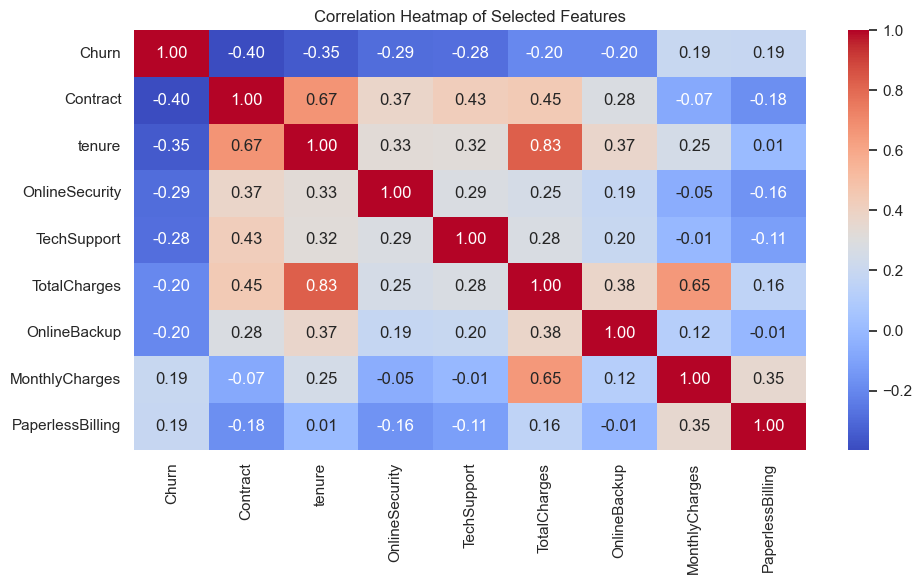

In [19]:
selected_columns = ['Churn'] + corr_with_target.head(8).index.tolist()
plt.figure(figsize=(10, 6))
sns.heatmap(encoded_df[selected_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Selected Features')
plt.tight_layout()
plt.show()

## 7. Phân phối các biến số trước và sau scale

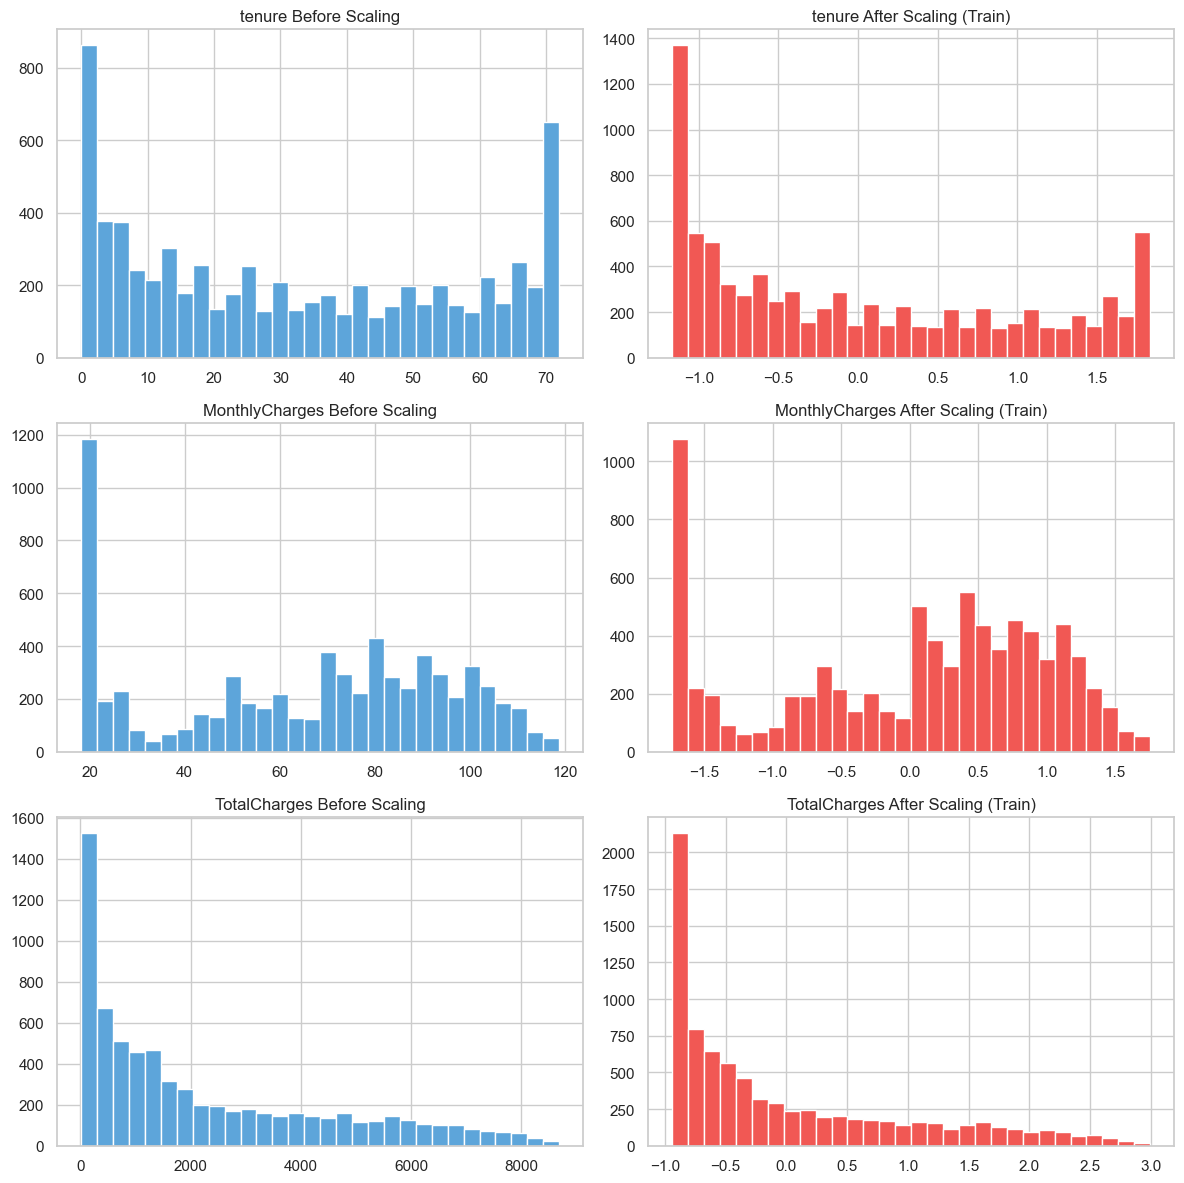

In [20]:
numeric_to_show = [col for col in ['tenure', 'MonthlyCharges', 'TotalCharges'] if col in bundle.numeric_columns]
fig, axes = plt.subplots(len(numeric_to_show), 2, figsize=(12, 4 * len(numeric_to_show)))
if len(numeric_to_show) == 1:
    axes = np.array([axes])

for row_idx, col in enumerate(numeric_to_show):
    axes[row_idx, 0].hist(df_clean[col], bins=30, color='#5DA5DA', edgecolor='white')
    axes[row_idx, 0].set_title(f'{col} Before Scaling')
    axes[row_idx, 1].hist(bundle.X_train[col], bins=30, color='#F15854', edgecolor='white')
    axes[row_idx, 1].set_title(f'{col} After Scaling (Train)')

plt.tight_layout()
plt.show()

## 8. Kết luận preprocessing

Các ý có thể chốt:
- `TotalCharges` là cột phải xử lý kỹ trước khi train.
- `customerID` bị loại bỏ vì không mang ý nghĩa dự đoán.
- Dữ liệu gồm cả numeric và categorical, nên encode là bắt buộc.
- `SMOTENC` giúp cân bằng lớp churn tốt hơn trong tập train.
- Correlation với `Churn` cho thấy một số biến như `Contract`, `tenure`, `MonthlyCharges` đáng chú ý để đưa vào phân tích.